In [1]:
# Functions and Dependencies
import numpy as np
from icing_true import ICINGTrue
from icing_model import ICINGModel
from particle_filter import BootstrapParticleFilter
from ext_kalman_filter import ExtendedKalmanFilter
from utils import gen_uex_func, gen_PN_func, gen_D_func, gen_SI_func
rng = np.random.default_rng()

In [2]:
# Basic simulation parameters
sim_hours = 60
dt = 1.0
t = np.arange(0, sim_hours*60+1, dt) #0 to 60 hours with minute-level resolution
y0 = [8.0, 15.0, 15.0, 0.0, 0.0] #Initial conditions: G, I, Q, P1, P2
D_const = 0
SI_const = 2e-4
uex_func = gen_uex_func()
PN_func = gen_PN_func()
D_func = gen_D_func(D_const)
SI_func = gen_SI_func(SI_const)

In [3]:
#  Simulation of true dynamics
gt_model = ICINGTrue()
G_true, I_true, Q_true, P1_true, P2_true = gt_model.simulate(y0, t[0], t[-1], t, uex_func, PN_func, D_func, SI_func)            

In [4]:
# ICING Model Initialization
t_meas = np.arange(0, sim_hours*60+1, 120.0) #0 to 60 hours with minute-level resolution
sample_indices = [np.argmin(np.abs(t - st)) for st in t_meas]
measurement_noise_std = 0.25
G_meas = G_true[sample_indices] + rng.normal(0, measurement_noise_std, size=len(sample_indices))
initial_state = np.append(y0[:3], [gt_model.params['k1']*np.exp(-y0[2]*gt_model.params['k2']/gt_model.params["k3"]), 2e-4])
process_noises = 1e-4/120*np.ones_like(initial_state)
process_noises[-1] = (1e-6)**2/120
input_functions = {"D": D_func, "PN": PN_func, "Uex": uex_func}
model = ICINGModel(params=None,dt=dt, initial_state=initial_state + 0.1*initial_state, process_noise_vars=process_noises, measurement_noise_var=measurement_noise_std**2, u_funcs=input_functions)

In [5]:
num_states = len(initial_state)
filter = ExtendedKalmanFilter(num_states=num_states, model=model)
filter.initialize_filter()
filter.R

0.0625

In [6]:
# Run Extended Kalman Filter
num_states = len(initial_state)
filter = ExtendedKalmanFilter(num_states=num_states, model=model)
sim = filter.simulate(t, t_meas, G_meas, filter)
saved_state, saved_noise_var, G_est, Q_est, I_est, Uen_est, SI_est, G_pred = sim.run()

Got measurement 0 at time 0
Predicting the next 2 hours...
Got measurement 1 at time 120
Predicting the next 2 hours...
Got measurement 2 at time 240
Predicting the next 2 hours...
Got measurement 3 at time 360
Predicting the next 2 hours...
Got measurement 4 at time 480
Predicting the next 2 hours...
Got measurement 5 at time 600
Predicting the next 2 hours...
Got measurement 6 at time 720
Predicting the next 2 hours...
Got measurement 7 at time 840
Predicting the next 2 hours...
Got measurement 8 at time 960
Predicting the next 2 hours...
Got measurement 9 at time 1080
Predicting the next 2 hours...
Got measurement 10 at time 1200
Predicting the next 2 hours...
Got measurement 11 at time 1320
Predicting the next 2 hours...
Got measurement 12 at time 1440
Predicting the next 2 hours...
Got measurement 13 at time 1560
Predicting the next 2 hours...
Got measurement 14 at time 1680
Predicting the next 2 hours...
Got measurement 15 at time 1800
Predicting the next 2 hours...
Got measureme

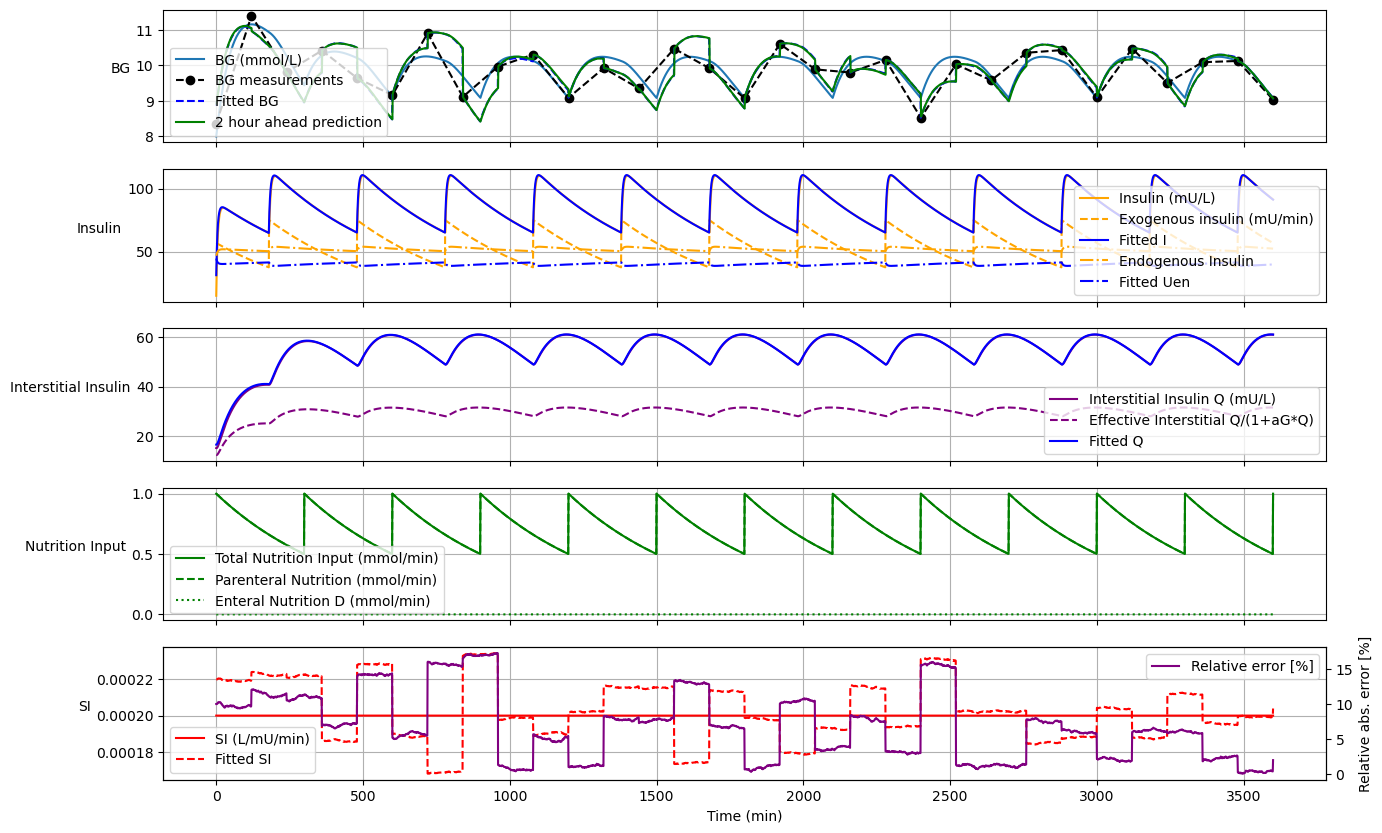

In [7]:
# Plot Extended Kalman Fitler 
ts = [119, 120, 121, 125]
sim.plot(saved_state, saved_noise_var, G_est, Q_est, I_est, Uen_est, SI_est, G_pred, I_true, gt_model)

In [8]:
# Run Particle Filter
# num_particles = 500
# filter = BootstrapParticleFilter(num_particles=num_particles, num_states=num_states, model=model)
# sim = filter.simuluate(t, t_meas, G_meas, filter)
# initial_particles, initial_weights, saved_particles, saved_weights, G_est, Q_est, I_est, Uen_est, SI_est, G_pred = sim.run()


In [9]:
# # Plot Particle filter
# ts = [119, 120, 121, 125]
# scale = 1e4
# sim.plot(initial_particles, initial_weights, saved_particles, saved_weights, G_est, Q_est, I_est, Uen_est, SI_est, G_pred, I_true, ts, scale, gt_model)